In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings, os, json
from datetime import datetime
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import joblib

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
os.makedirs('charts', exist_ok=True)
os.makedirs('models', exist_ok=True)
print("Setup complete.")


Setup complete.


In [2]:
# Try xlsx first, fall back to csv
try:
    df = pd.read_excel('data/OnlineRetail.xlsx', engine='openpyxl')
    print("Loaded from Excel")
except Exception as e:
    print(f"Failed to load Excel: {e}. Trying CSV...")
    try:
        df = pd.read_csv('data/OnlineRetail.csv', encoding='ISO-8859-1', sep=';', decimal=',')
        print("Loaded from CSV with semicolon separator")
    except Exception as e2:
        print(f"Failed to load with semicolon: {e2}. Trying default CSV...")
        df = pd.read_csv('data/OnlineRetail.csv', encoding='ISO-8859-1')
        print("Loaded from CSV")

print(f"Shape: {df.shape}")
print(f"\nColumn types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nSample data:")
df.head()


Failed to load Excel: [Errno 2] No such file or directory: 'data/OnlineRetail.xlsx'. Trying CSV...
Loaded from CSV with semicolon separator
Shape: (541909, 8)

Column types:
InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID       int64
Country            str
dtype: object

Missing values:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

Sample data:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,1.12.2010 08:26,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,1.12.2010 08:26,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,1.12.2010 08:26,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,1.12.2010 08:26,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,1.12.2010 08:26,3.39,17850,United Kingdom


In [3]:
print(f"Original shape: {df.shape}")

# Step 1: Parse InvoiceDate as datetime
try:
    df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], dayfirst=True)
    print("Parsed dates with dayfirst=True")
except Exception as e:
    print(f"Failed parsing with dayfirst=True: {e}. Trying default parsing...")
    df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Step 2: Remove cancelled orders (InvoiceNo starts with 'C')
cancelled = df[df['InvoiceNo'].astype(str).str.startswith('C')].shape[0]
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
print(f"Removed {cancelled} cancelled orders")

# Step 3: Remove invalid Quantity (zero or negative)
df = df[df['Quantity'] > 0]

# Step 4: Remove invalid UnitPrice (zero or negative)
df = df[df['UnitPrice'] > 0]

# Step 5: Drop rows with missing Description
df = df.dropna(subset=['Description'])

# Step 6: Create TotalPrice column
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Step 7: Add time-based columns for analysis
df['Year']        = df['InvoiceDate'].dt.year
df['Month']       = df['InvoiceDate'].dt.month
df['MonthName']   = df['InvoiceDate'].dt.strftime('%b')
df['DayOfWeek']   = df['InvoiceDate'].dt.dayofweek
df['DayName']     = df['InvoiceDate'].dt.strftime('%A')
df['Hour']        = df['InvoiceDate'].dt.hour
df['YearMonth']   = df['InvoiceDate'].dt.to_period('M').astype(str)
df['Quarter']     = df['InvoiceDate'].dt.quarter

# Step 8: Separate clean dataframe WITH CustomerID for RFM
df_rfm = df.dropna(subset=['CustomerID']).copy()
df_rfm['CustomerID'] = df_rfm['CustomerID'].astype(int)

print(f"After cleaning (all): {df.shape}")
print(f"After cleaning (with CustomerID for RFM): {df_rfm.shape}")
print(f"Date range: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")
print(f"Unique customers: {df_rfm['CustomerID'].nunique()}")
print(f"Unique products: {df['StockCode'].nunique()}")
print(f"Unique countries: {df['Country'].nunique()}")
print(f"Total revenue: £{df['TotalPrice'].sum():,.2f}")


Original shape: (541909, 8)
Parsed dates with dayfirst=True
Removed 9288 cancelled orders
After cleaning (all): (530104, 17)
After cleaning (with CustomerID for RFM): (530104, 17)
Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00
Unique customers: 4339
Unique products: 3922
Unique countries: 38
Total revenue: £10,666,684.54


In [4]:
total_revenue    = df['TotalPrice'].sum()
total_orders     = df['InvoiceNo'].nunique()
total_customers  = df_rfm['CustomerID'].nunique()
total_products   = df['StockCode'].nunique()
avg_order_value  = df.groupby('InvoiceNo')['TotalPrice'].sum().mean()
avg_items_order  = df.groupby('InvoiceNo')['Quantity'].sum().mean()
top_country      = df.groupby('Country')['TotalPrice'].sum().idxmax()

print("=" * 50)
print("KEY BUSINESS METRICS")
print("=" * 50)
print(f"Total Revenue       : £{total_revenue:>12,.2f}")
print(f"Total Orders        : {total_orders:>12,}")
print(f"Total Customers     : {total_customers:>12,}")
print(f"Total Products      : {total_products:>12,}")
print(f"Avg Order Value     : £{avg_order_value:>12,.2f}")
print(f"Avg Items per Order : {avg_items_order:>12,.1f}")
print(f"Top Country         : {top_country:>12}")
print("=" * 50)

kpis = {
    'total_revenue'   : round(total_revenue, 2),
    'total_orders'    : int(total_orders),
    'total_customers' : int(total_customers),
    'total_products'  : int(total_products),
    'avg_order_value' : round(avg_order_value, 2),
    'top_country'     : top_country
}
with open('models/kpis.json', 'w') as f:
    json.dump(kpis, f, indent=2)
print("KPIs saved to models/kpis.json")


KEY BUSINESS METRICS
Total Revenue       : £10,666,684.54
Total Orders        :       19,960
Total Customers     :        4,339
Total Products      :        3,922
Avg Order Value     : £      534.40
Avg Items per Order :        280.0
Top Country         : United Kingdom
KPIs saved to models/kpis.json


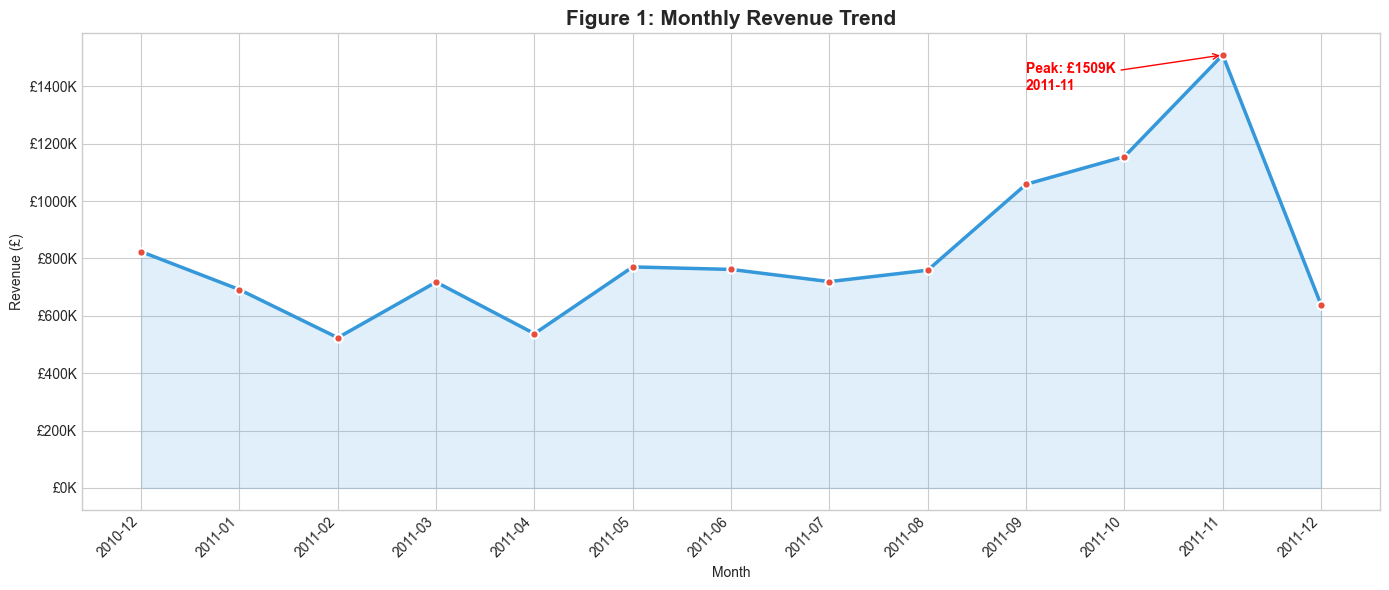

Peak revenue month: 2011-11 — £1,509,496


In [5]:
monthly_revenue = (df.groupby('YearMonth')['TotalPrice']
                   .sum().reset_index())
monthly_revenue.columns = ['YearMonth', 'Revenue']
monthly_revenue = monthly_revenue.sort_values('YearMonth')

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(monthly_revenue['YearMonth'], monthly_revenue['Revenue'],
        color='#3498db', linewidth=2.5, marker='o', markersize=6,
        markerfacecolor='#e74c3c', markeredgecolor='white', markeredgewidth=1.5)
ax.fill_between(range(len(monthly_revenue)),
                monthly_revenue['Revenue'], alpha=0.15, color='#3498db')
ax.set_xticks(range(len(monthly_revenue)))
ax.set_xticklabels(monthly_revenue['YearMonth'], rotation=45, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'£{x/1000:.0f}K'))
ax.set_title('Figure 1: Monthly Revenue Trend', fontsize=15, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (£)')

# Annotate peak month
peak_idx = monthly_revenue['Revenue'].idxmax()
peak_val = monthly_revenue['Revenue'].max()
peak_month = monthly_revenue.loc[peak_idx, 'YearMonth']
ax.annotate(f'Peak: £{peak_val/1000:.0f}K\n{peak_month}',
            xy=(list(monthly_revenue['YearMonth']).index(peak_month), peak_val),
            xytext=(list(monthly_revenue['YearMonth']).index(peak_month) - 2,
                    peak_val * 0.92),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=10, color='red', fontweight='bold')

plt.tight_layout()
plt.savefig('charts/01_monthly_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Peak revenue month: {peak_month} — £{peak_val:,.0f}")


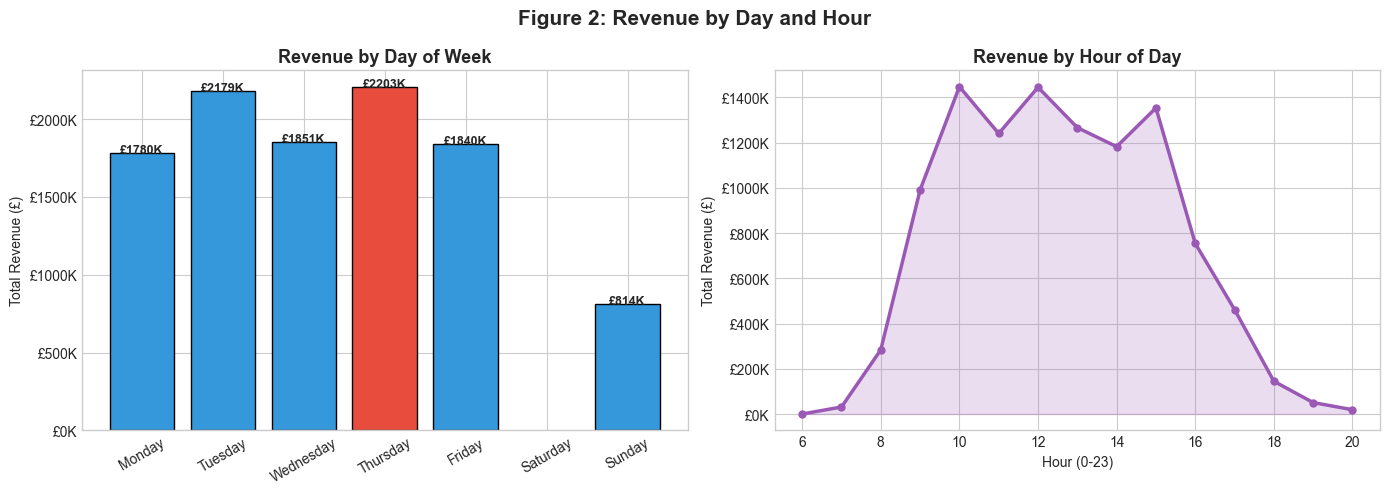

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Revenue by day of week
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_revenue = (df.groupby('DayName')['TotalPrice'].sum()
               .reindex(day_order))
colors_dow = ['#e74c3c' if d == dow_revenue.idxmax() else '#3498db'
              for d in day_order]
bars1 = axes[0].bar(dow_revenue.index, dow_revenue.values,
                    color=colors_dow, edgecolor='black')
axes[0].set_title('Revenue by Day of Week', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Total Revenue (£)')
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
axes[0].tick_params(axis='x', rotation=30)
for bar, val in zip(bars1, dow_revenue.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 1000,
                 f'£{val/1000:.0f}K', ha='center', fontsize=9, fontweight='bold')

# Revenue by hour of day
hour_revenue = df.groupby('Hour')['TotalPrice'].sum()
axes[1].plot(hour_revenue.index, hour_revenue.values,
             color='#9b59b6', linewidth=2.5, marker='o', markersize=5)
axes[1].fill_between(hour_revenue.index, hour_revenue.values,
                     alpha=0.2, color='#9b59b6')
axes[1].set_title('Revenue by Hour of Day', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Total Revenue (£)')
axes[1].set_xlabel('Hour (0-23)')
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))

plt.suptitle('Figure 2: Revenue by Day and Hour', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/02_day_hour_revenue.png', dpi=150, bbox_inches='tight')
plt.show()


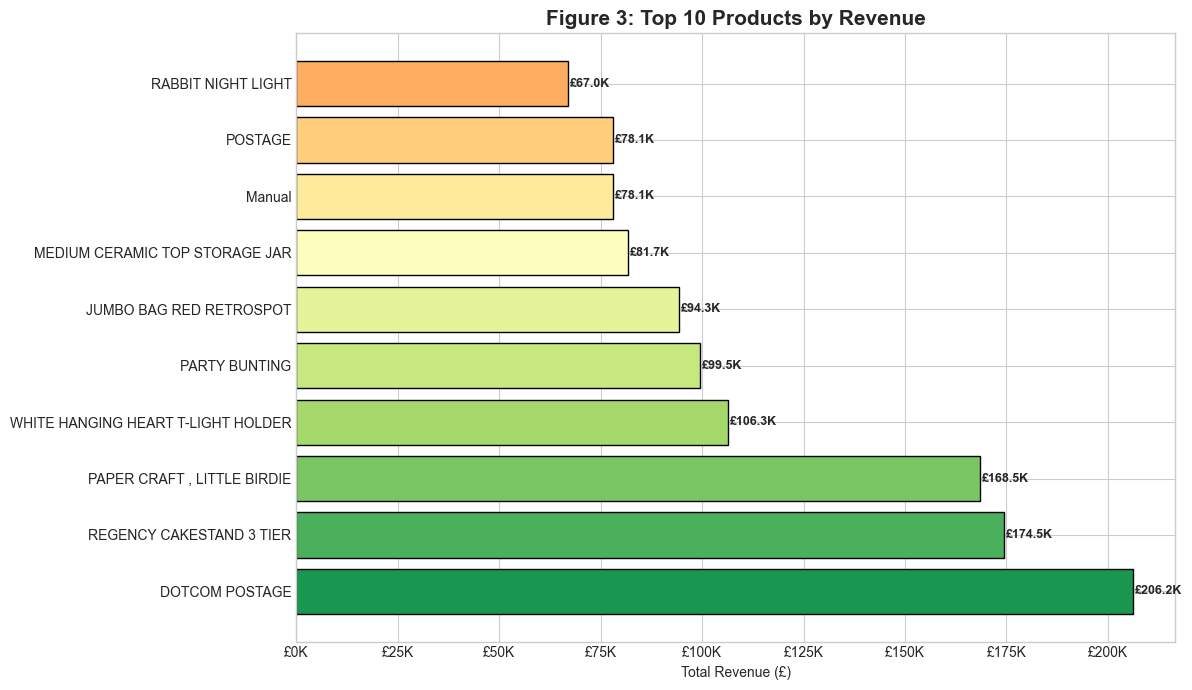

Top 5 products by revenue:
  DOTCOM POSTAGE                                     £206,248.77
  REGENCY CAKESTAND 3 TIER                           £174,484.74
  PAPER CRAFT , LITTLE BIRDIE                        £168,469.60
  WHITE HANGING HEART T-LIGHT HOLDER                 £106,292.77
  PARTY BUNTING                                      £ 99,504.33


In [7]:
top_products = (df.groupby('Description')['TotalPrice']
                .sum().sort_values(ascending=False).head(10))

fig, ax = plt.subplots(figsize=(12, 7))
colors_p = plt.cm.RdYlGn(np.linspace(0.3, 0.9, 10))
bars_p = ax.barh(range(len(top_products)), top_products.values,
                 color=colors_p[::-1], edgecolor='black')
ax.set_yticks(range(len(top_products)))
ax.set_yticklabels([name[:45] for name in top_products.index],
                   fontsize=10)
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
ax.set_title('Figure 3: Top 10 Products by Revenue',
             fontsize=15, fontweight='bold')
ax.set_xlabel('Total Revenue (£)')
for bar, val in zip(bars_p, top_products.values):
    ax.text(val + 500, bar.get_y() + bar.get_height()/2,
            f'£{val/1000:.1f}K', va='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/03_top_products.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 5 products by revenue:")
for prod, rev in top_products.head(5).items():
    print(f"  {prod[:50]:50} £{rev:>10,.2f}")


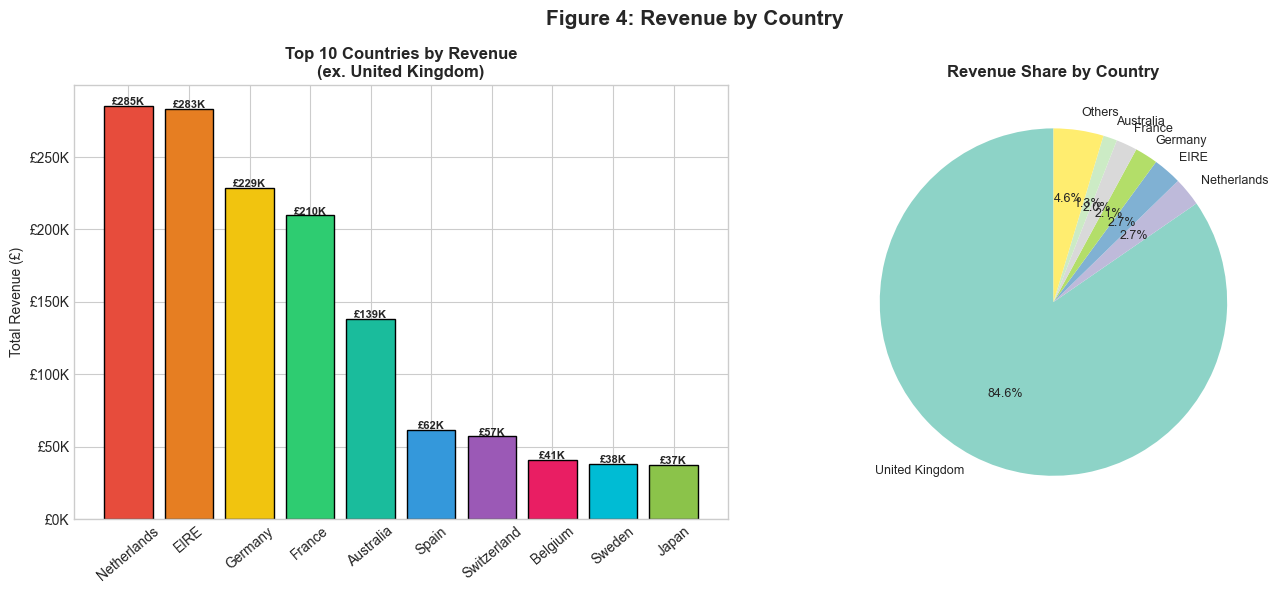

In [8]:
top_countries = (df[df['Country'] != 'United Kingdom']
                 .groupby('Country')['TotalPrice']
                 .sum().sort_values(ascending=False).head(10))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart — top 10 ex-UK
colors_c = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#1abc9c',
            '#3498db','#9b59b6','#e91e63','#00bcd4','#8bc34a']
bars_c = axes[0].bar(top_countries.index, top_countries.values,
                     color=colors_c, edgecolor='black')
axes[0].set_title('Top 10 Countries by Revenue\n(ex. United Kingdom)',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Total Revenue (£)')
axes[0].tick_params(axis='x', rotation=40)
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
for bar, val in zip(bars_c, top_countries.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 500,
                 f'£{val/1000:.0f}K', ha='center', fontsize=8, fontweight='bold')

# All countries including UK — pie chart
all_countries = df.groupby('Country')['TotalPrice'].sum()
top_c_pie = all_countries.sort_values(ascending=False).head(6)
other_val = all_countries.sort_values(ascending=False).iloc[6:].sum()
pie_data = pd.concat([top_c_pie, pd.Series({'Others': other_val})])
axes[1].pie(pie_data.values, labels=pie_data.index,
            autopct='%1.1f%%', startangle=90,
            colors=plt.cm.Set3(np.linspace(0, 1, len(pie_data))),
            textprops={'fontsize': 9})
axes[1].set_title('Revenue Share by Country', fontsize=12, fontweight='bold')

plt.suptitle('Figure 4: Revenue by Country', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/04_country_revenue.png', dpi=150, bbox_inches='tight')
plt.show()


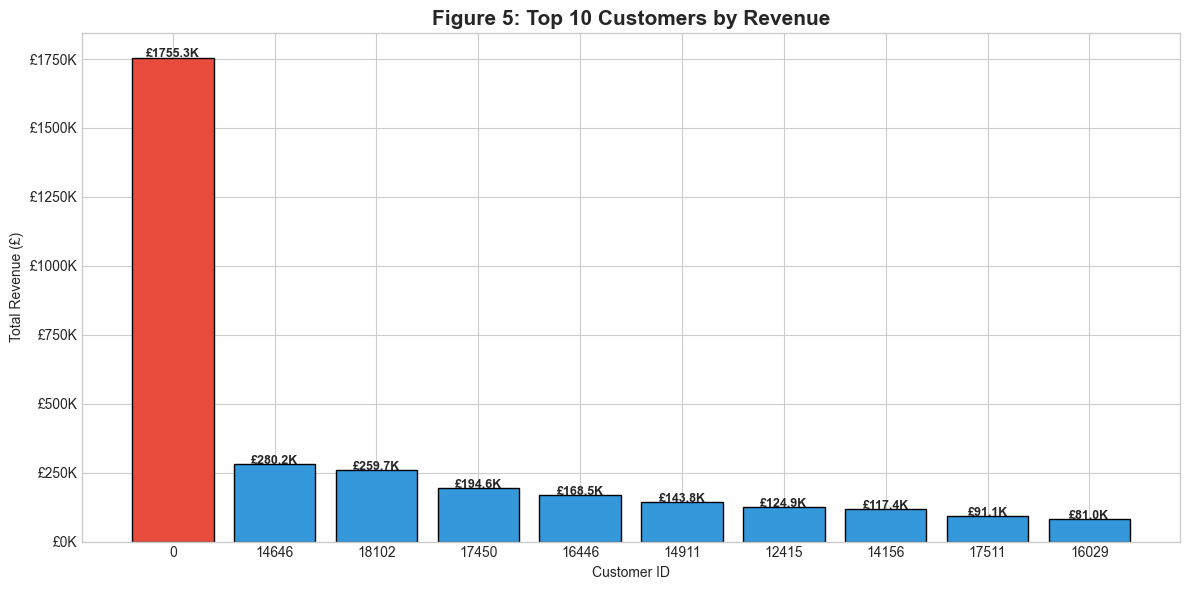

In [9]:
top_customers = (df_rfm.groupby('CustomerID')['TotalPrice']
                 .sum().sort_values(ascending=False).head(10))

fig, ax = plt.subplots(figsize=(12, 6))
colors_cust = ['#e74c3c' if i == 0 else '#3498db'
               for i in range(len(top_customers))]
bars_cu = ax.bar([str(int(c)) for c in top_customers.index],
                 top_customers.values,
                 color=colors_cust, edgecolor='black')
ax.set_title('Figure 5: Top 10 Customers by Revenue',
             fontsize=15, fontweight='bold')
ax.set_xlabel('Customer ID')
ax.set_ylabel('Total Revenue (£)')
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
for bar, val in zip(bars_cu, top_customers.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 200,
            f'£{val/1000:.1f}K', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/05_top_customers.png', dpi=150, bbox_inches='tight')
plt.show()


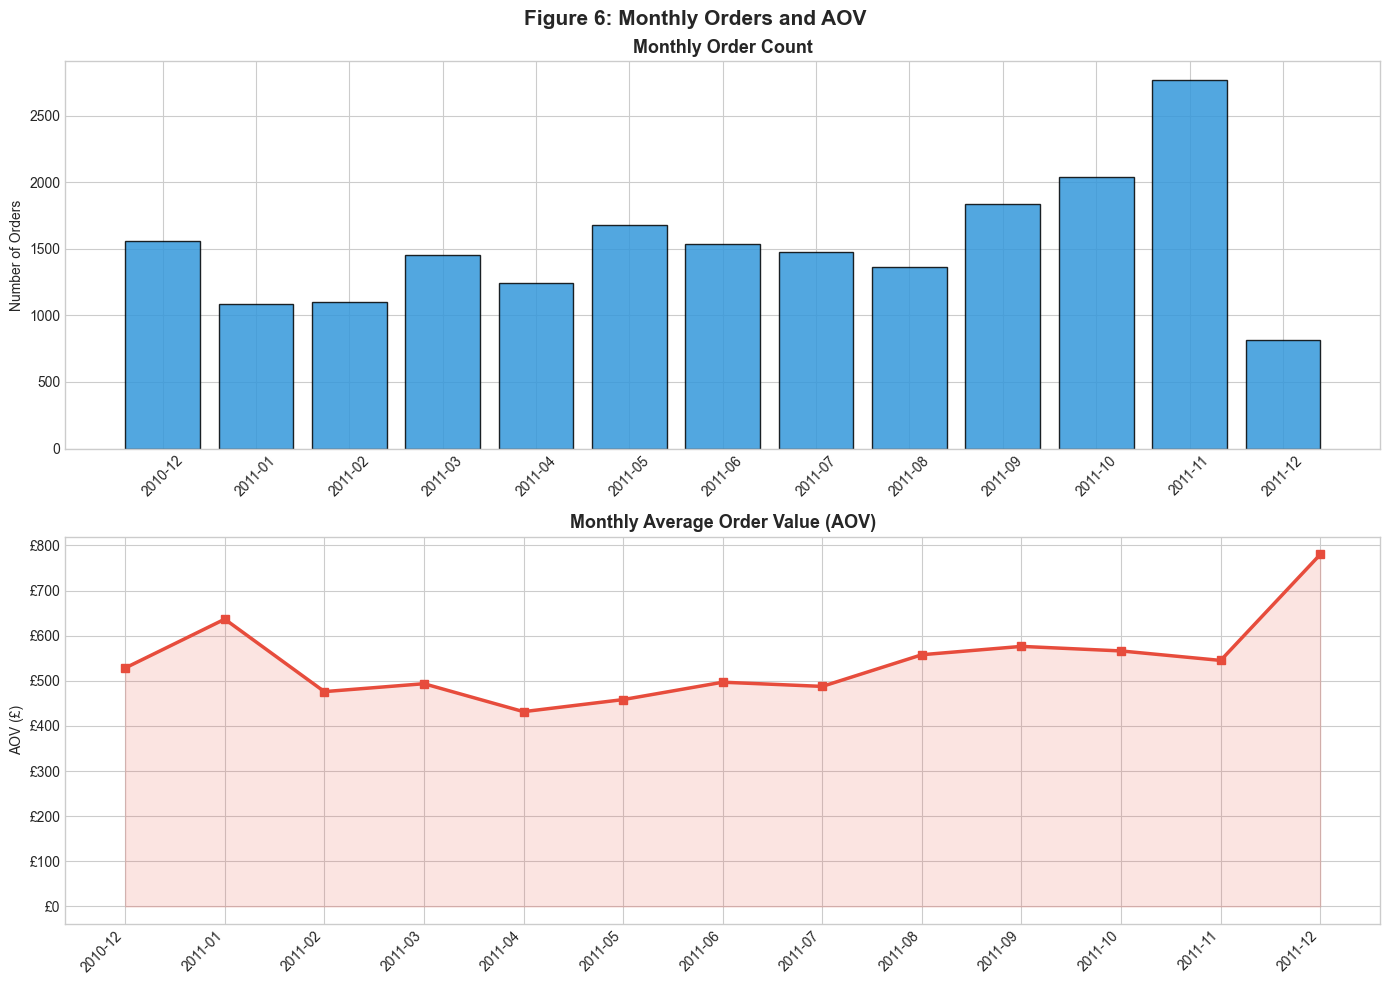

In [10]:
monthly_orders = df.groupby('YearMonth')['InvoiceNo'].nunique().reset_index()
monthly_orders.columns = ['YearMonth', 'OrderCount']
monthly_aov = (df.groupby(['YearMonth','InvoiceNo'])['TotalPrice']
               .sum().reset_index()
               .groupby('YearMonth')['TotalPrice'].mean()
               .reset_index())
monthly_aov.columns = ['YearMonth', 'AOV']

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].bar(monthly_orders['YearMonth'], monthly_orders['OrderCount'],
            color='#3498db', edgecolor='black', alpha=0.85)
axes[0].set_title('Monthly Order Count', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Orders')
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(monthly_aov['YearMonth'], monthly_aov['AOV'],
             color='#e74c3c', linewidth=2.5, marker='s', markersize=6)
axes[1].fill_between(range(len(monthly_aov)),
                     monthly_aov['AOV'], alpha=0.15, color='#e74c3c')
axes[1].set_xticks(range(len(monthly_aov)))
axes[1].set_xticklabels(monthly_aov['YearMonth'], rotation=45, ha='right')
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x:.0f}'))
axes[1].set_title('Monthly Average Order Value (AOV)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('AOV (£)')

plt.suptitle('Figure 6: Monthly Orders and AOV', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/06_orders_aov.png', dpi=150, bbox_inches='tight')
plt.show()


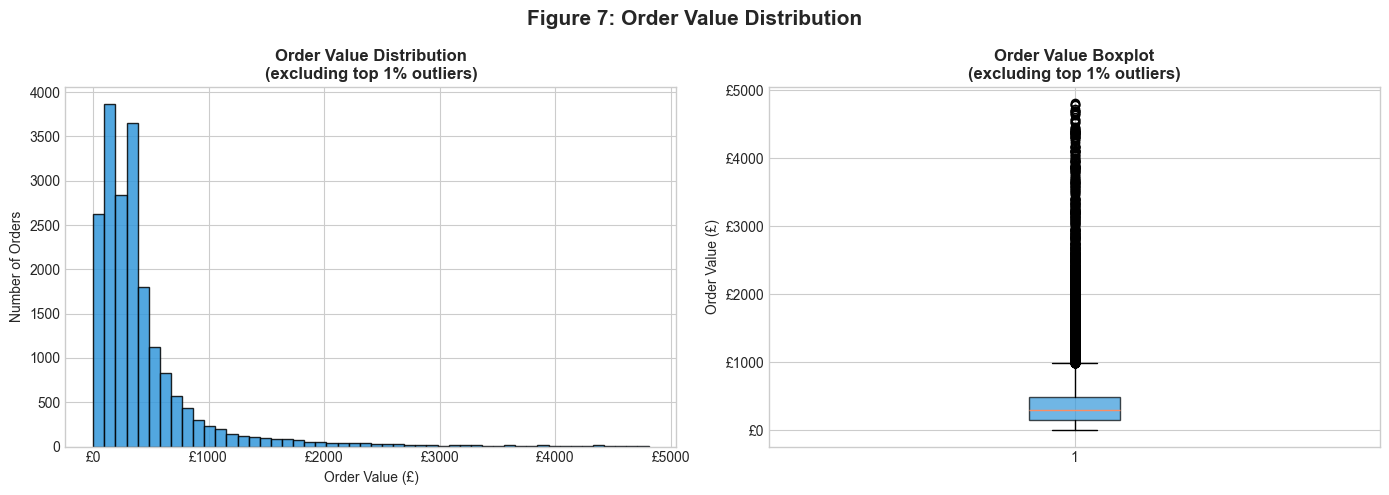

Order value stats:
  Mean   : £534.40
  Median : £303.84
  Std    : £1,780.49
  Min    : £0.38
  Max    : £168,469.60


In [11]:
order_values = df.groupby('InvoiceNo')['TotalPrice'].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(order_values[order_values < order_values.quantile(0.99)],
             bins=50, color='#3498db', edgecolor='black', alpha=0.85)
axes[0].set_title('Order Value Distribution\n(excluding top 1% outliers)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Order Value (£)')
axes[0].set_ylabel('Number of Orders')
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x:.0f}'))

axes[1].boxplot(order_values[order_values < order_values.quantile(0.99)],
                vert=True, patch_artist=True,
                boxprops=dict(facecolor='#3498db', alpha=0.7))
axes[1].set_title('Order Value Boxplot\n(excluding top 1% outliers)',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Order Value (£)')
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x:.0f}'))

plt.suptitle('Figure 7: Order Value Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/07_order_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Order value stats:")
print(f"  Mean   : £{order_values.mean():,.2f}")
print(f"  Median : £{order_values.median():,.2f}")
print(f"  Std    : £{order_values.std():,.2f}")
print(f"  Min    : £{order_values.min():,.2f}")
print(f"  Max    : £{order_values.max():,.2f}")


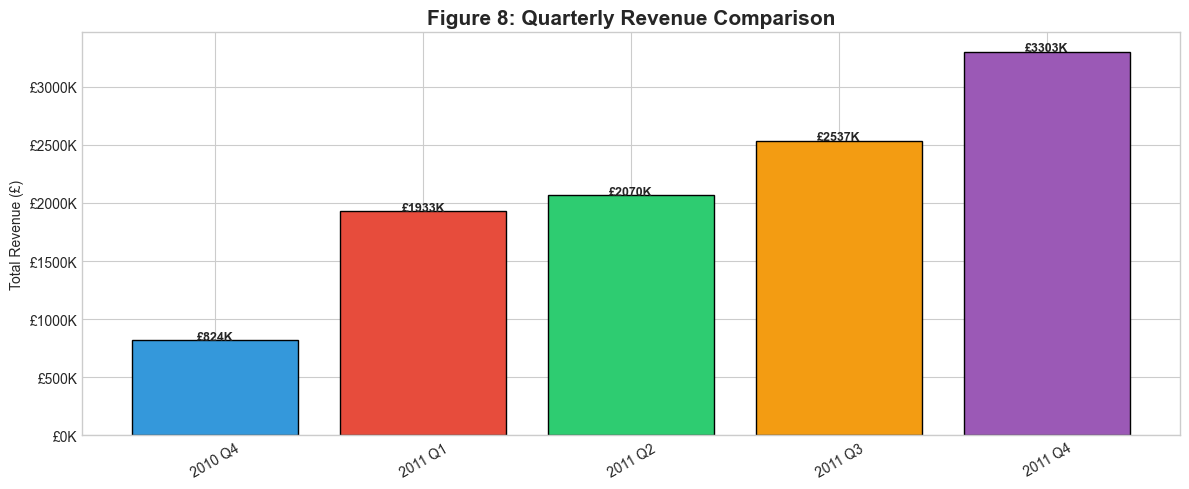

In [12]:
quarterly = df.groupby(['Year', 'Quarter'])['TotalPrice'].sum().reset_index()
quarterly['Label'] = quarterly['Year'].astype(str) + ' Q' + quarterly['Quarter'].astype(str)

fig, ax = plt.subplots(figsize=(12, 5))
colors_q = ['#3498db','#e74c3c','#2ecc71','#f39c12',
            '#9b59b6','#1abc9c','#e67e22','#e91e63']
bars_q = ax.bar(quarterly['Label'], quarterly['TotalPrice'],
                color=colors_q[:len(quarterly)], edgecolor='black')
ax.set_title('Figure 8: Quarterly Revenue Comparison',
             fontsize=15, fontweight='bold')
ax.set_ylabel('Total Revenue (£)')
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
ax.tick_params(axis='x', rotation=30)
for bar, val in zip(bars_q, quarterly['TotalPrice']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1000,
            f'£{val/1000:.0f}K', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/08_quarterly_revenue.png', dpi=150, bbox_inches='tight')
plt.show()


In [13]:
# RFM = Recency, Frequency, Monetary
# Recency  : How recently did the customer buy?
# Frequency: How often do they buy?
# Monetary : How much do they spend?

snapshot_date = df_rfm['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df_rfm.groupby('CustomerID').agg(
    Recency  =('InvoiceDate',  lambda x: (snapshot_date - x.max()).days),
    Frequency=('InvoiceNo',    'nunique'),
    Monetary =('TotalPrice',   'sum')
).reset_index()

print(f"RFM table shape: {rfm.shape}")
print(f"\nRFM summary statistics:")
print(rfm[['Recency','Frequency','Monetary']].describe().round(2))

# Score each metric 1-5 (5 = best)
rfm['R_Score'] = pd.qcut(rfm['Recency'],   5, labels=[5,4,3,2,1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5,
                          labels=[1,2,3,4,5]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'],  5, labels=[1,2,3,4,5]).astype(int)
rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

# Segment customers based on RFM Score
def rfm_segment(score):
    if score >= 13:  return 'Champions'
    elif score >= 10: return 'Loyal Customers'
    elif score >= 7:  return 'Potential Loyalists'
    elif score >= 5:  return 'At Risk'
    else:             return 'Lost Customers'

rfm['Segment'] = rfm['RFM_Score'].apply(rfm_segment)

print(f"\nCustomer segments:")
print(rfm['Segment'].value_counts())
print(f"\nRevenue by segment:")
print(rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)
        .apply(lambda x: f'£{x:,.0f}'))


RFM table shape: (4339, 4)

RFM summary statistics:
       Recency  Frequency    Monetary
count  4339.00    4339.00     4339.00
mean     92.52       4.60     2458.33
std     100.01      22.94    28092.65
min       1.00       1.00        3.75
25%      18.00       1.00      307.43
50%      51.00       2.00      674.52
75%     142.00       5.00     1662.06
max     374.00    1428.00  1755276.64

Customer segments:
Segment
Potential Loyalists    1094
Loyal Customers        1007
Champions               934
At Risk                 759
Lost Customers          545
Name: count, dtype: int64

Revenue by segment:
Segment
Champions              £8,008,554
Loyal Customers        £1,409,759
Potential Loyalists      £883,543
At Risk                  £259,878
Lost Customers           £104,951
Name: Monetary, dtype: str


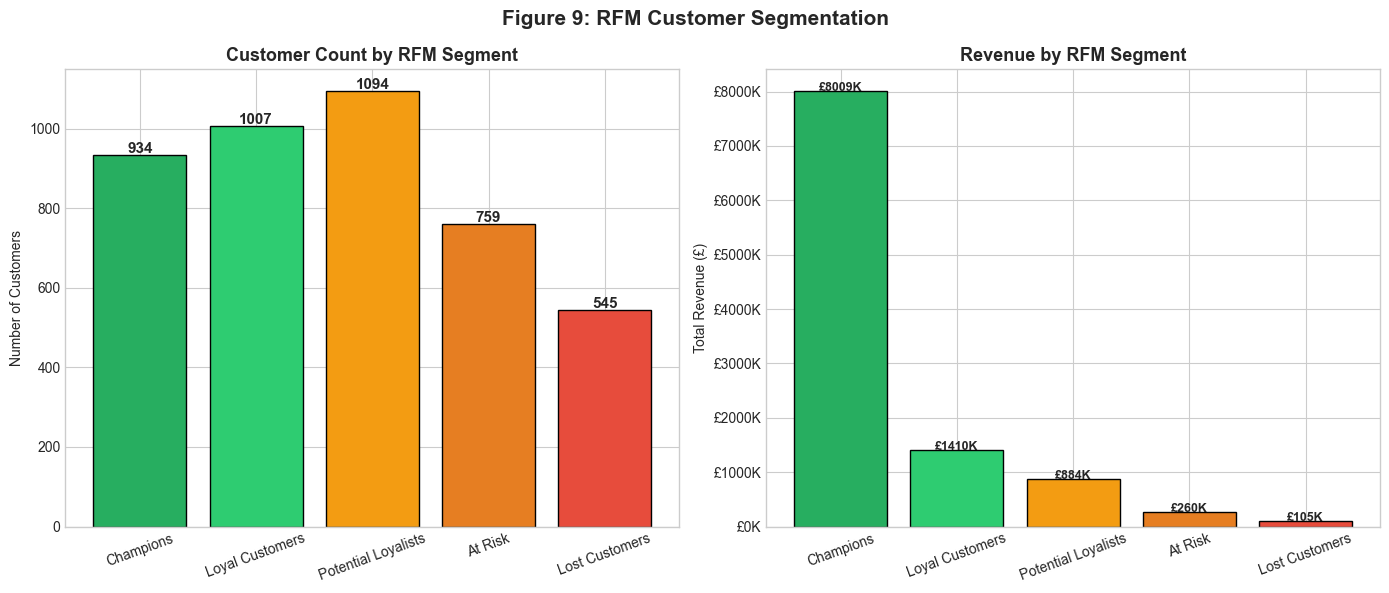

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Count per segment
seg_counts = rfm['Segment'].value_counts()
seg_order  = ['Champions','Loyal Customers','Potential Loyalists',
               'At Risk','Lost Customers']
seg_colors = ['#27ae60','#2ecc71','#f39c12','#e67e22','#e74c3c']

seg_plot = seg_counts.reindex(seg_order)
bars_s = axes[0].bar(seg_plot.index, seg_plot.values,
                     color=seg_colors, edgecolor='black')
axes[0].set_title('Customer Count by RFM Segment',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=20)
for bar, val in zip(bars_s, seg_plot.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 5,
                 str(val), ha='center', fontsize=11, fontweight='bold')

# Revenue per segment
seg_revenue = rfm.groupby('Segment')['Monetary'].sum().reindex(seg_order)
bars_sr = axes[1].bar(seg_revenue.index, seg_revenue.values,
                      color=seg_colors, edgecolor='black')
axes[1].set_title('Revenue by RFM Segment', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Total Revenue (£)')
axes[1].tick_params(axis='x', rotation=20)
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
for bar, val in zip(bars_sr, seg_revenue.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 1000,
                 f'£{val/1000:.0f}K', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Figure 9: RFM Customer Segmentation', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/09_rfm_segments.png', dpi=150, bbox_inches='tight')
plt.show()


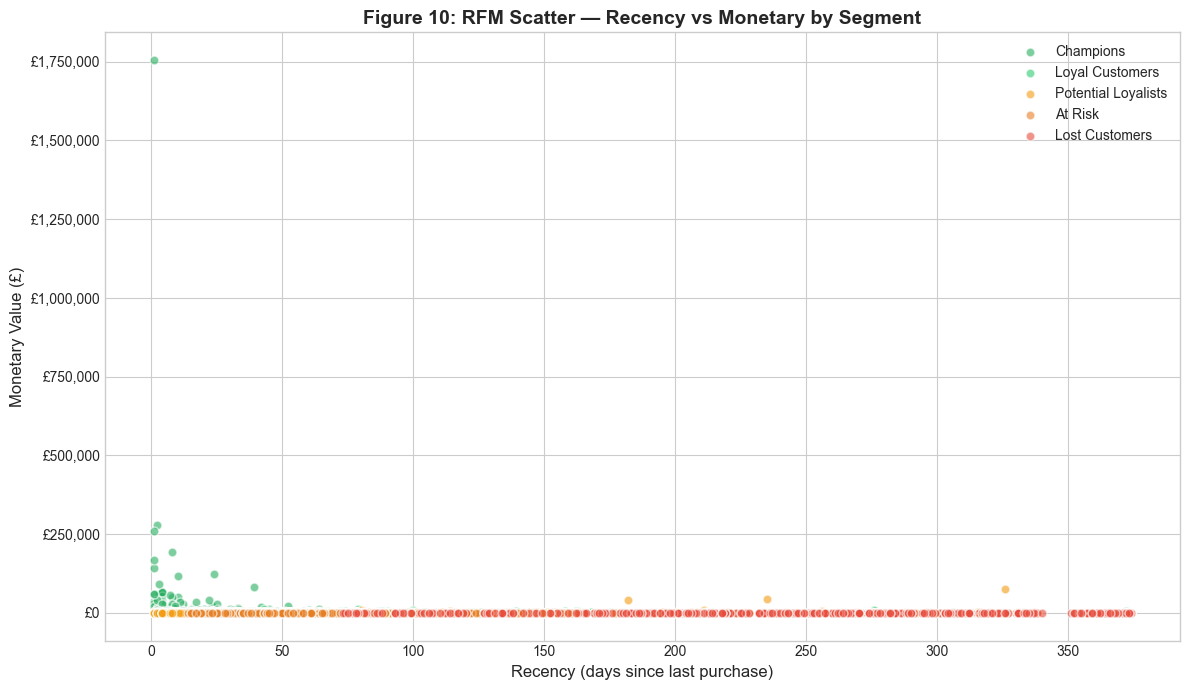

In [15]:
fig, ax = plt.subplots(figsize=(12, 7))
seg_color_map = {
    'Champions'          : '#27ae60',
    'Loyal Customers'    : '#2ecc71',
    'Potential Loyalists': '#f39c12',
    'At Risk'            : '#e67e22',
    'Lost Customers'     : '#e74c3c'
}
for segment, color in seg_color_map.items():
    mask = rfm['Segment'] == segment
    ax.scatter(rfm.loc[mask, 'Recency'],
               rfm.loc[mask, 'Monetary'],
               c=color, label=segment, alpha=0.6, s=40, edgecolors='white')

ax.set_xlabel('Recency (days since last purchase)', fontsize=12)
ax.set_ylabel('Monetary Value (£)', fontsize=12)
ax.set_title('Figure 10: RFM Scatter — Recency vs Monetary by Segment',
             fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.tight_layout()
plt.savefig('charts/10_rfm_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


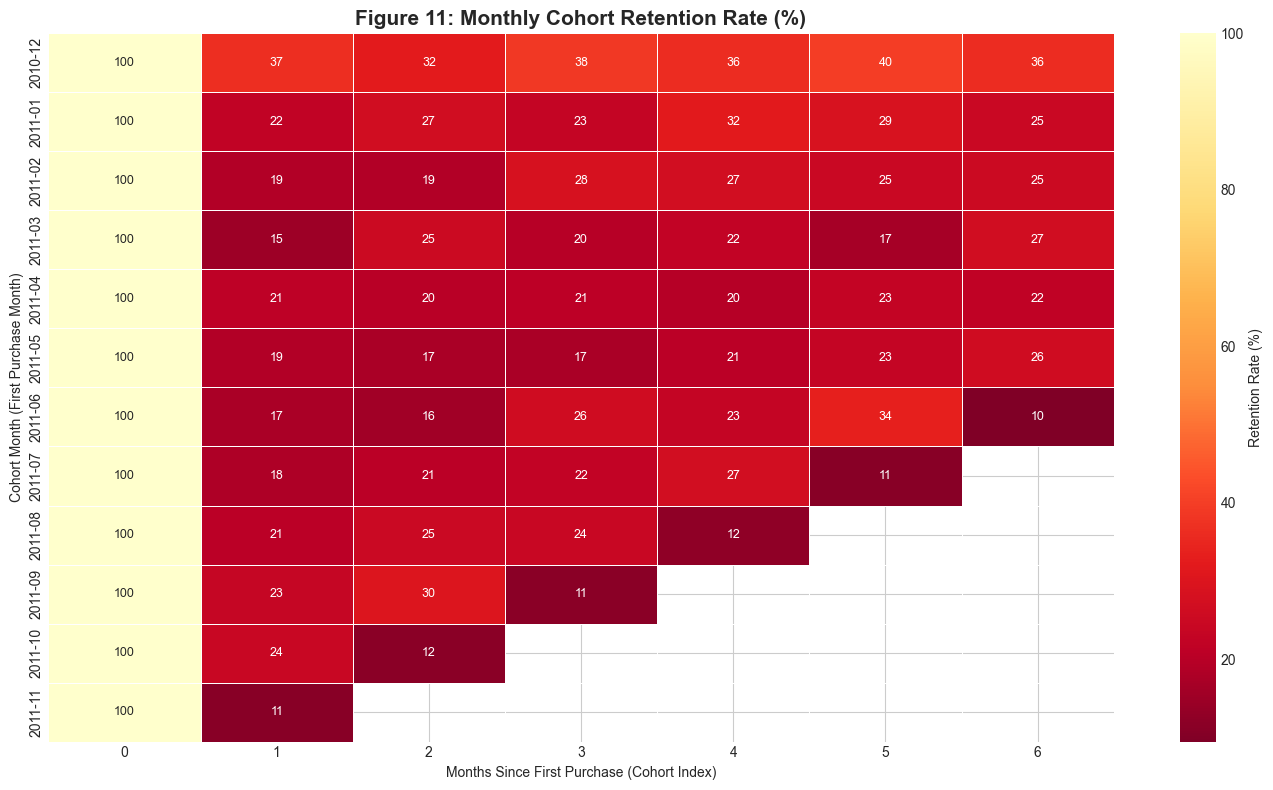

Cohort 0 (first month retention) = 100% by definition
Cohort 1 = % of month-0 customers who returned in month 1
Average Month-1 retention across cohorts: 20.6%


In [16]:
# Cohort Analysis: track retention of customers acquired each month

df_cohort = df_rfm.copy()
df_cohort['InvoiceMonth']  = df_cohort['InvoiceDate'].dt.to_period('M')
df_cohort['CohortMonth']   = (df_cohort.groupby('CustomerID')['InvoiceDate']
                               .transform('min').dt.to_period('M'))
df_cohort['CohortIndex']   = ((df_cohort['InvoiceMonth'] -
                                df_cohort['CohortMonth'])
                               .apply(lambda x: x.n))

cohort_data = (df_cohort.groupby(['CohortMonth','CohortIndex'])['CustomerID']
               .nunique().reset_index())
cohort_pivot = cohort_data.pivot(index='CohortMonth',
                                  columns='CohortIndex',
                                  values='CustomerID')
cohort_sizes = cohort_pivot[0]
cohort_pct   = cohort_pivot.divide(cohort_sizes, axis=0).round(3) * 100

# Plot — show first 12 cohort months and first 6 periods
plot_cohort = cohort_pct.iloc[:12, :7]

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(plot_cohort, annot=True, fmt='.0f', cmap='YlOrRd_r',
            ax=ax, linewidths=0.5,
            annot_kws={'size': 9},
            cbar_kws={'label': 'Retention Rate (%)'})
ax.set_title('Figure 11: Monthly Cohort Retention Rate (%)',
             fontsize=15, fontweight='bold')
ax.set_xlabel('Months Since First Purchase (Cohort Index)')
ax.set_ylabel('Cohort Month (First Purchase Month)')
plt.tight_layout()
plt.savefig('charts/11_cohort_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Cohort 0 (first month retention) = 100% by definition")
print("Cohort 1 = % of month-0 customers who returned in month 1")
avg_m1_retention = plot_cohort[1].mean()
print(f"Average Month-1 retention across cohorts: {avg_m1_retention:.1f}%")


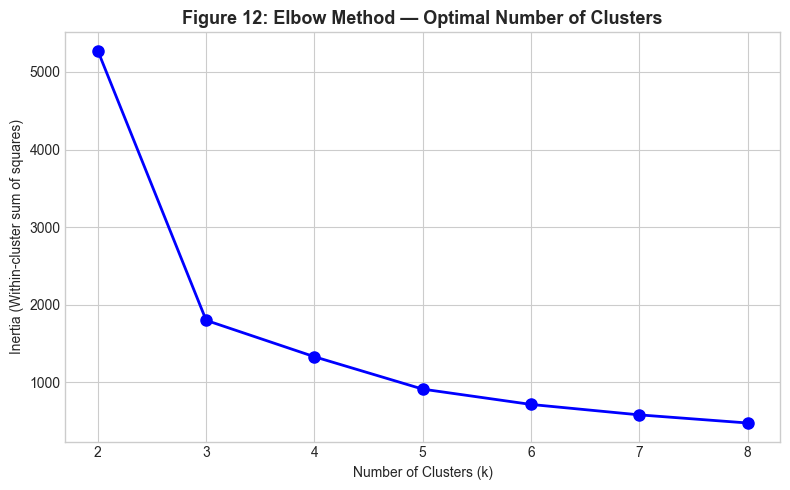


Cluster Summary (mean RFM values):
         Recency  Frequency   Monetary
Cluster                               
0          152.4        2.2      794.8
1            1.0     1428.0  1755276.6
2          294.4        1.4      607.2
3           31.9        5.5     2724.0

Cluster Labels:
ClusterLabel
High Value - Active     2894
Low Value - Inactive    1445
Name: count, dtype: int64

Models and RFM table saved.


In [17]:
# Cluster customers into 4 groups using RFM values
rfm_scaled = rfm[['Recency','Frequency','Monetary']].copy()

scaler_rfm = StandardScaler()
rfm_scaled_arr = scaler_rfm.fit_transform(rfm_scaled)

# Find optimal k using elbow method
inertias = []
k_range  = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled_arr)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(k_range), inertias, 'bo-', linewidth=2, markersize=8)
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia (Within-cluster sum of squares)')
ax.set_title('Figure 12: Elbow Method — Optimal Number of Clusters',
             fontsize=13, fontweight='bold')
ax.set_xticks(list(k_range))
plt.tight_layout()
plt.savefig('charts/12_elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()

# Fit with k=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled_arr)

cluster_summary = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean().round(1)
print("\nCluster Summary (mean RFM values):")
print(cluster_summary)

# Label clusters by their characteristics
def label_cluster(row):
    if row['Monetary'] > cluster_summary['Monetary'].median() and        row['Recency'] < cluster_summary['Recency'].median():
        return 'High Value - Active'
    elif row['Monetary'] > cluster_summary['Monetary'].median():
        return 'High Value - Inactive'
    elif row['Recency'] < cluster_summary['Recency'].median():
        return 'Low Value - Active'
    else:
        return 'Low Value - Inactive'

cluster_labels = cluster_summary.apply(label_cluster, axis=1)
rfm['ClusterLabel'] = rfm['Cluster'].map(cluster_labels)

print("\nCluster Labels:")
print(rfm['ClusterLabel'].value_counts())

joblib.dump(kmeans,      'models/kmeans_model.pkl')
joblib.dump(scaler_rfm,  'models/rfm_scaler.pkl')
rfm.to_csv('models/rfm_table.csv', index=False)
print("\nModels and RFM table saved.")


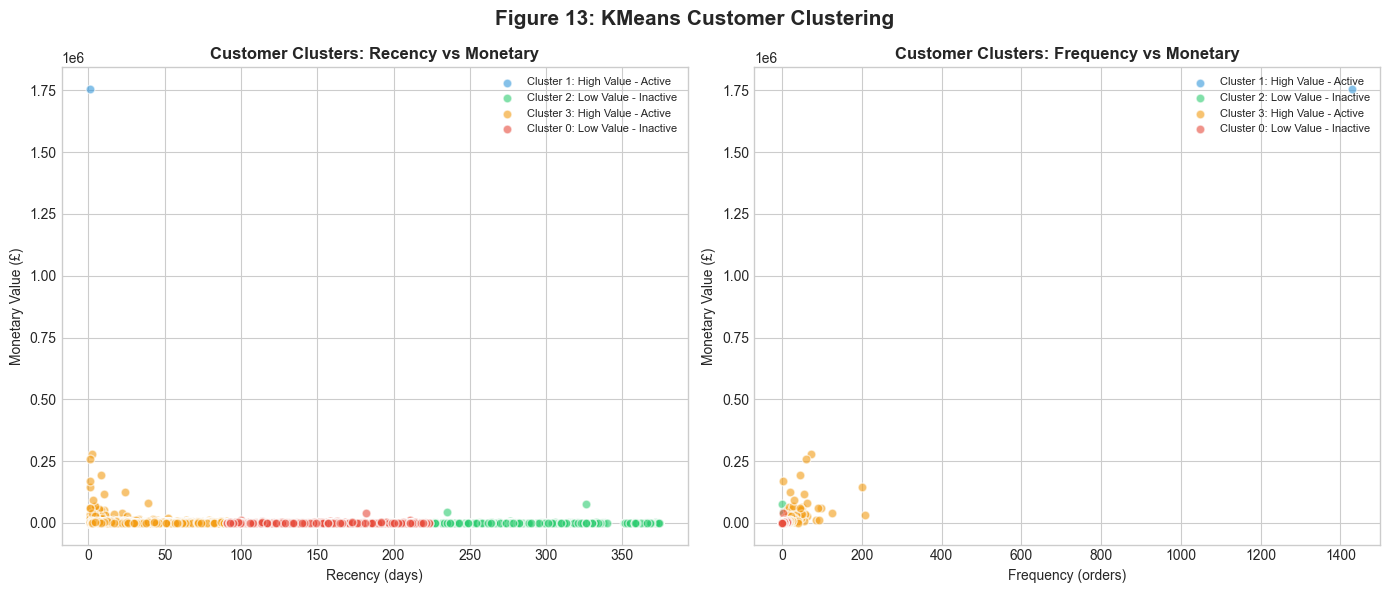

In [18]:
cluster_colors = ['#e74c3c','#3498db','#2ecc71','#f39c12']
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter: Recency vs Monetary colored by cluster
for cluster_id in rfm['Cluster'].unique():
    mask = rfm['Cluster'] == cluster_id
    label = rfm.loc[mask, 'ClusterLabel'].iloc[0]
    axes[0].scatter(rfm.loc[mask, 'Recency'],
                    rfm.loc[mask, 'Monetary'],
                    c=cluster_colors[cluster_id],
                    label=f'Cluster {cluster_id}: {label}',
                    alpha=0.6, s=40, edgecolors='white')
axes[0].set_xlabel('Recency (days)')
axes[0].set_ylabel('Monetary Value (£)')
axes[0].set_title('Customer Clusters: Recency vs Monetary',
                  fontsize=12, fontweight='bold')
axes[0].legend(fontsize=8, loc='upper right')

# Scatter: Frequency vs Monetary
for cluster_id in rfm['Cluster'].unique():
    mask = rfm['Cluster'] == cluster_id
    label = rfm.loc[mask, 'ClusterLabel'].iloc[0]
    axes[1].scatter(rfm.loc[mask, 'Frequency'],
                    rfm.loc[mask, 'Monetary'],
                    c=cluster_colors[cluster_id],
                    label=f'Cluster {cluster_id}: {label}',
                    alpha=0.6, s=40, edgecolors='white')
axes[1].set_xlabel('Frequency (orders)')
axes[1].set_ylabel('Monetary Value (£)')
axes[1].set_title('Customer Clusters: Frequency vs Monetary',
                  fontsize=12, fontweight='bold')
axes[1].legend(fontsize=8, loc='upper right')

plt.suptitle('Figure 13: KMeans Customer Clustering', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/13_customer_clusters.png', dpi=150, bbox_inches='tight')
plt.show()


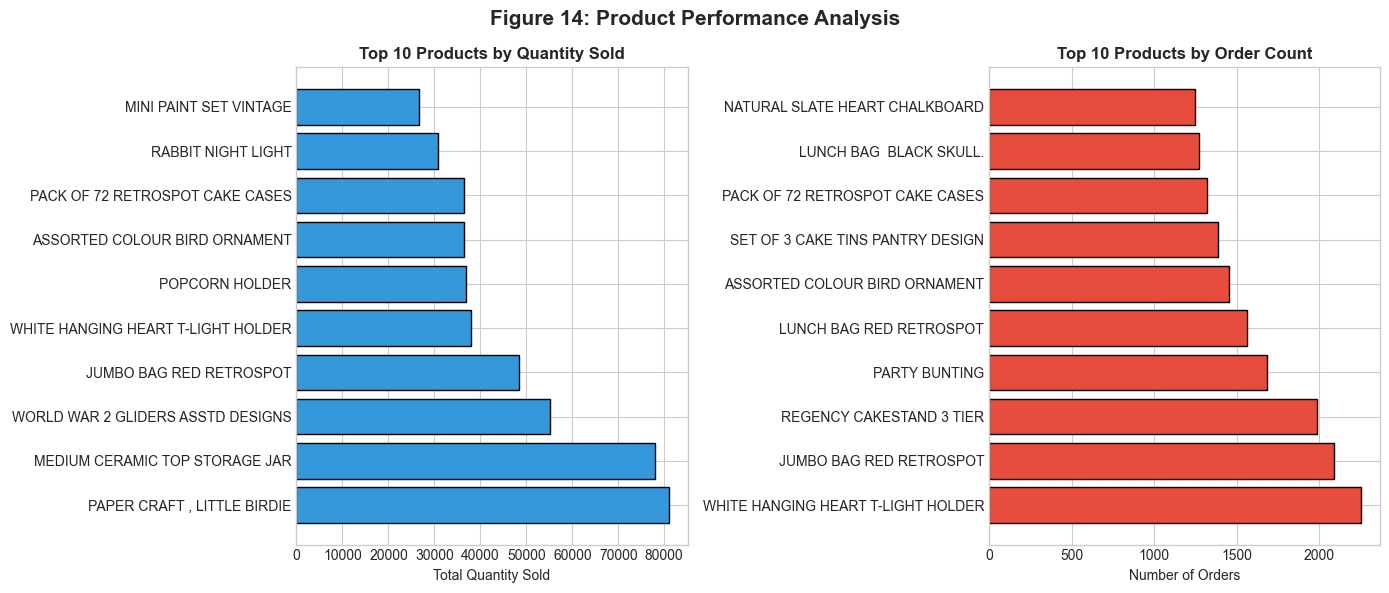

In [19]:
product_stats = df.groupby('Description').agg(
    TotalQuantity=('Quantity',   'sum'),
    TotalRevenue =('TotalPrice', 'sum'),
    OrderCount   =('InvoiceNo',  'nunique')
).reset_index()
product_stats['AvgUnitPrice'] = (product_stats['TotalRevenue'] /
                                  product_stats['TotalQuantity'])
product_stats = product_stats.sort_values('TotalRevenue', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top 10 by quantity sold
top_qty = product_stats.sort_values('TotalQuantity', ascending=False).head(10)
axes[0].barh([d[:35] for d in top_qty['Description']],
             top_qty['TotalQuantity'],
             color='#3498db', edgecolor='black')
axes[0].set_title('Top 10 Products by Quantity Sold',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Total Quantity Sold')

# Top 10 by number of orders
top_orders = product_stats.sort_values('OrderCount', ascending=False).head(10)
axes[1].barh([d[:35] for d in top_orders['Description']],
             top_orders['OrderCount'],
             color='#e74c3c', edgecolor='black')
axes[1].set_title('Top 10 Products by Order Count',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Orders')

plt.suptitle('Figure 14: Product Performance Analysis',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/14_product_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


In [20]:
print(f"""
Project Summary
===============
Dataset    : UCI Online Retail
Period     : {df['InvoiceDate'].min().date()} to {df['InvoiceDate'].max().date()}
Transactions: {df.shape[0]:,} (after cleaning)
Customers  : {df_rfm['CustomerID'].nunique():,} unique

Revenue Metrics
---------------
Total Revenue     : £{df['TotalPrice'].sum():,.2f}
Total Orders      : {df['InvoiceNo'].nunique():,}
Avg Order Value   : £{df.groupby('InvoiceNo')['TotalPrice'].sum().mean():,.2f}
Top Country       : {df.groupby('Country')['TotalPrice'].sum().idxmax()}

RFM Segments
------------
{rfm['Segment'].value_counts().to_string()}

Cluster Summary
---------------
{rfm['ClusterLabel'].value_counts().to_string()}

Charts saved : 14 (charts/ folder)
Models saved : kmeans_model.pkl, rfm_scaler.pkl, rfm_table.csv, kpis.json
""")



Project Summary
Dataset    : UCI Online Retail
Period     : 2010-12-01 to 2011-12-09
Transactions: 530,104 (after cleaning)
Customers  : 4,339 unique

Revenue Metrics
---------------
Total Revenue     : £10,666,684.54
Total Orders      : 19,960
Avg Order Value   : £534.40
Top Country       : United Kingdom

RFM Segments
------------
Segment
Potential Loyalists    1094
Loyal Customers        1007
Champions               934
At Risk                 759
Lost Customers          545

Cluster Summary
---------------
ClusterLabel
High Value - Active     2894
Low Value - Inactive    1445

Charts saved : 14 (charts/ folder)
Models saved : kmeans_model.pkl, rfm_scaler.pkl, rfm_table.csv, kpis.json

